In [89]:
#Question 1
def read_pref_etu(f):
    fichier = open(f, "r")           # Ouverture du fichier en mode lecture "r"
    contenu = fichier.readlines()    # Liste contenant chaque ligne du fichier
    fichier.close()                  # Fermeture du fichier

    nbEtu = int(contenu[0])
    matrix = [[] for i in range(nbEtu)]
    agent=[]
    contenu = contenu[1:]            # On retire la 1ere ligne (nombre d'etudiants)

    for ligne in contenu:
        l = ligne.split()            # Liste contenant chaque element de la ligne separe par un espace
        numEtu = int(l[0])
        nomEtu = l[1]
        agent.append(l[0])
        l = l[2:]                    # On retire les 2 premiers elements (numero + nom)
        matrix[numEtu] = l

    return matrix,agent
def read_pref_spe(f):
    fichier = open(f, "r")           # Ouverture du fichier en mode lecture "r"
    contenu = fichier.readlines()    # Liste contenant chaque ligne du fichier
    fichier.close()                  # Fermeture du fichier
    agent=[]
    contenu = contenu[1:]            # On retire la 1ere ligne (nombre d'etudiants)

    # On met la capacite de chaque parcours dans une liste
    capacite = contenu[0].split()
    capacite = capacite[1:]              # On retire "Cap" de la liste
    for i in range(len(capacite)):
        capacite[i] = int(capacite[i])

    nbSpe = len(capacite)            # On recupere le nombre total de spe

    matrix = [[] for i in range(nbSpe)]

    contenu = contenu[1:]            # On retire la 1ere ligne (capacite des spe)

    for ligne in contenu:
        l = ligne.split()            # Liste contenant chaque element de la ligne separe par un espace
        numSpe = int(l[0])
        nomSpe = l[1]
        agent.append(l[0])
        l = l[2:]                    # On retire les 2 premiers elements (numero + nom)
        matrix[numSpe] = l

    return matrix, capacite,agent

In [90]:
matrix_pref_etu,agent_m = read_pref_etu("PrefEtu.txt")
matrix_pref_spe, capacite, agent_w = read_pref_spe("PrefSpe.txt")

In [91]:
matrix_pref_etu

[['5', '7', '6', '8', '3', '2', '0', '1', '4'],
 ['6', '5', '0', '4', '7', '2', '8', '3', '1'],
 ['4', '0', '7', '2', '8', '3', '1', '6', '5'],
 ['6', '5', '7', '0', '8', '4', '3', '1', '2'],
 ['1', '6', '7', '5', '0', '2', '4', '8', '3'],
 ['0', '7', '4', '2', '8', '3', '1', '6', '5'],
 ['5', '7', '6', '2', '8', '3', '0', '1', '4'],
 ['7', '0', '4', '2', '8', '3', '1', '6', '5'],
 ['5', '7', '6', '2', '8', '3', '0', '1', '4'],
 ['2', '6', '5', '8', '3', '1', '4', '7', '0'],
 ['6', '4', '0', '8', '3', '1', '5', '2', '7']]

In [92]:
agent_m

['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

In [93]:
matrix_pref_spe

[['7', '9', '5', '4', '3', '1', '0', '10', '6', '8', '2'],
 ['7', '5', '9', '4', '3', '1', '0', '10', '8', '6', '2'],
 ['3', '9', '5', '4', '7', '6', '1', '0', '10', '8', '2'],
 ['7', '9', '5', '4', '3', '1', '0', '6', '10', '8', '2'],
 ['10', '3', '0', '4', '5', '6', '7', '8', '9', '1', '2'],
 ['1', '0', '3', '4', '5', '6', '7', '2', '9', '10', '8'],
 ['0', '1', '3', '4', '5', '6', '7', '2', '8', '10', '9'],
 ['7', '6', '9', '5', '4', '3', '1', '0', '10', '8', '2'],
 ['1', '0', '3', '4', '5', '6', '7', '2', '9', '10', '8']]

In [94]:
print(agent_w)
print(capacite)

['0', '1', '2', '3', '4', '5', '6', '7', '8']
[2, 1, 1, 1, 1, 1, 1, 1, 2]


In [95]:
#Question 3
def gale_shapleyV3(maListeH,maListeF,current_man,current_women,taille_max):
    """
    maListeH -> list*list*str : les preferences des hommes(etudiant)
    maListeF -> list*list*str : les preferences des femmes(master)
    current_man -> list*str : liste des hommes
    current_women -> list*str : liste des femmes
    taille_max -> capacite maximun des preferences des femmes
    
    La fonction applique l algo de gale shapley du cote des etudiants
    
    Return : la solution de gale shapley
    """
    
    couple={}#la solution final de gale shapley
    taille={j: 0 for j in current_women} #dictionnaire sur la capacite actuelle des femmes (master) qui est initialise a 0
    position = {j: 0 for j in current_man} #dictionnaire sur la postion actuelle des preferences des hommes (etudiant) qui est initialise a 0
    agent=[x for x in range(len(current_man))]#la file d attente des hommes(etudiant)
    
    #Debut de l'algo 
    while agent!=[]:
        
        i=agent[0]
        #verifie si l'agent est libre mais theoriquement les agents sont libres
        if current_man[i] not in couple.keys():
            free_man=current_man[i]
            target=maListeH[i][position[free_man]]
            
            #verifie si la target n est pas encore pris ou s il reste de la place
            if (target not in couple.values()) or (taille[target]<int(taille_max[int(target)])):
                couple[free_man]=target
                taille[target]+=1 
                agent.pop(0)
                
            #sinon il va regarder dans les preferences de la femme, pour voir qui est le meilleur pour elle
            else:
                liste_cle=[free_man]
                tmp=couple.copy()
                taille[target]=0
                position[free_man]+=1
                
                #cherche les autres agents qui ont le meme target que lui
                for cle,valeur in couple.items():
                    if target==valeur:
                        liste_cle.append(cle)
                        position[cle]+=1
                        tmp.pop(cle,valeur)
                        agent.append(int(cle))
                        
                #regarde les parametres du target pour garder que ces pref        
                for x in range(len(maListeF[int(target)])):
                    #regarde un par un de la gauche vers la droite, et si la preference est dans la liste de cle alors il ajoute
                    if maListeF[int(target)][x] in liste_cle:
                        tmp[maListeF[int(target)][x]]=target
                        position[maListeF[int(target)][x]]-=1
                        taille[target]+=1
                        agent.remove(int(maListeF[int(target)][x]))
                    if taille[target]>=int(taille_max[int(target)]):#quand la capacite est atteint, il arrete la boucle
                        couple=tmp.copy()
                        break
    return couple

In [96]:
result_etu_gale=gale_shapleyV3(matrix_pref_etu, matrix_pref_spe,agent_m,agent_w,capacite)
print(result_etu_gale)

{'4': '1', '0': '5', '10': '4', '1': '6', '5': '0', '3': '0', '7': '7', '9': '2', '6': '8', '2': '8', '8': '3'}


In [97]:
#Question 4
def gale_shapley_parcours(maListeH,maListeF,current_man,current_women,taille_max):
    
    """
    maListeH -> list*list*str : les preferences des hommes(etudiant)
    maListeF -> list*list*str : les preferences des femmes(master)
    current_man -> list*str : liste des hommes
    current_women -> list*str : liste des femmes
    taille_max -> capacite maximun des preferences des femmes
    
    La fonction applique l algo de gale shapley du cote des masters
    
    Return : la solution de gale shapley
    """
    
    couple={j: [] for j in current_man}#la solution final de gale shapley
    position = {j: 0 for j in current_man}#dictionnaire sur la postion actuelle des preferences des hommes (etudiant) qui est initialise a 0
    agent=[x for x in range(len(current_man))]#la file d attente des hommes(etudiant)
    
    #Debut de l algo
    while agent!=[]:
        i=agent[0]
        
        #verifie si l'agent est libre mais theoriquement les agents sont libres
        if couple[current_man[i]]==[] or len(couple[current_man[i]])<taille_max[i]:
            free_man=current_man[i]
            target=maListeH[i][position[free_man]]
            
            #Si la target est deja pris par lui meme
            if target in couple[free_man]:
                position[free_man]+=1
                continue
            
            #verifie si la target n est pas encore pris 
            if not(any(target in liste for liste in couple.values())):
                couple[free_man].append(maListeH[i][position[free_man]])
                #si la capacite max n est pas atteint alors il augment de 1 la position
                if len(couple[current_man[i]])<taille_max[i]:
                    position[free_man]+=1
                #sinon il retire de la file d attente
                else:
                    agent.pop(0)
                    
            #sinon il va regarder dans les preferences de la femme,pour voir qui est le meilleur pour elle
            else:
                liste_cle=[free_man]
                tmp=couple.copy()
                position[free_man]+=1
                
                #cherche les autres agents qui ont le meme target que lui
                for cle,valeur in couple.items():
                    if target in valeur:
                        liste_cle.append(cle)
                        if (taille_max[int(cle)]-len(tmp[cle]))==0:#le cas si il a plusieurs preference
                            position[cle]+=1
                        tmp[cle].remove(target)
                        if int(cle) not in agent:#n ajoute pas les cles en double
                            agent.append(int(cle))
                        break
                        
                #regarde les parametres du target pour garder que ces pref  
                for x in range(len(maListeF[int(target)])):
                    #regarde un par un de la gauche vers la droite, et si la preference est dans la liste de cle alors il ajoute
                    if maListeF[int(target)][x] in liste_cle:
                        tmp[maListeF[int(target)][x]].append(target)
                        position[maListeF[int(target)][x]]-=1
                        #quand la capacite est atteint, il arrete la boucle
                        if len(couple[maListeF[int(target)][x]])>=taille_max[int(maListeF[int(target)][x])]:
                            agent.remove(int(maListeF[int(target)][x]))
                        break
                couple=tmp.copy()
    return couple

In [105]:
result_spe_gale=gale_shapley_parcours(matrix_pref_spe,matrix_pref_etu,agent_w,agent_m,capacite)
print(result_spe_gale)

{'0': ['5', '3'], '1': ['4'], '2': ['9'], '3': ['8'], '4': ['10'], '5': ['1'], '6': ['0'], '7': ['7'], '8': ['6', '2']}


In [99]:
#Question 6
def paire_instables(affectation, matrix_pref_etu, matrix_pref_spe):
    liste_paires_instables = []

    # On parcourt tous les parcours et les étudiants affectés
    for parcours1, liste_etudiants in affectation.items():
        for etudiant in liste_etudiants:
            liste_pref_etu = matrix_pref_etu[int(etudiant)]

            # Récupérer l'indice du parcours actuel dans les préférences de l'étudiant
            ind_etu_pref1 = liste_pref_etu.index(parcours1)

            # Comparer parcours1 avec tous les autres parcours possibles
            for parcours2 in affectation.keys():
                if parcours2 != parcours1:
                    #print(liste_pref_etu,parcours2)
                    ind_etu_pref2 = liste_pref_etu.index(str(parcours2))

                    # Si l'étudiant préfère parcours2 à parcours1
                    if ind_etu_pref2 < ind_etu_pref1:
                        liste_pref_parcours = matrix_pref_spe[int(parcours2)]

                        # Vérifier si parcours2 préfère aussi cet étudiant à ses affectés
                        for etudiant_affecte in affectation[parcours2]:
                            ind_etu_parcours2 = liste_pref_parcours.index(etudiant)
                            ind_etu_affecte_parcours2 = liste_pref_parcours.index(etudiant_affecte)

                            # Si parcours2 préfère l'étudiant à un de ses actuels affectés
                            if ind_etu_parcours2 < ind_etu_affecte_parcours2:
                                if (not((parcours2, etudiant) in liste_paires_instables)):
                                    liste_paires_instables.append((parcours2, etudiant))

    return liste_paires_instables

In [100]:
affectation = {'0': ['5', '3'], '1': ['4'], '2': ['9'], '3': ['8'], '4': ['10'], '5': ['1'], '6': ['0'], '7': ['7'], '8': ['6', '2']}
affectation2 = {'0': ['5', '3'], '1': ['4'], '2': ['9'], '3': ['8'], '4': ['10'], '5': ['1'], '6': ['0'], '7': ['6'], '8': ['7', '2']}
affectation3 = {'0': ['0', '1'], '1': ['2'], '2': ['3'], '3': ['4'], '4': ['5'], '5': ['6'], '6': ['7'], '7': ['8'], '8': ['9', '10']}
print("Liste des paires instables :", paire_instables(affectation, matrix_pref_etu, matrix_pref_spe))
print("Liste des paires instables :", paire_instables(affectation2, matrix_pref_etu, matrix_pref_spe))
print("Liste des paires instables :", paire_instables(affectation3, matrix_pref_etu, matrix_pref_spe))

Liste des paires instables : []
Liste des paires instables : [('0', '7'), ('7', '7')]
Liste des paires instables : [('5', '0'), ('6', '0'), ('7', '0'), ('8', '0'), ('5', '1'), ('6', '1'), ('8', '2'), ('0', '3'), ('1', '3'), ('4', '3'), ('5', '3'), ('6', '3'), ('7', '3'), ('8', '3'), ('0', '4'), ('1', '4'), ('4', '4'), ('5', '4'), ('6', '4'), ('7', '4'), ('8', '4'), ('0', '5'), ('7', '5'), ('0', '7'), ('1', '7'), ('3', '7'), ('7', '7'), ('8', '7'), ('4', '10')]


In [45]:
#Question 7
import random
import time
import matplotlib.pyplot as plt

In [14]:
def matrice_aleatoire(n_etu,n_spe):
    """
    n_etu -> nombre d etudiant
    n_spe -> nombre de spe
    Return : genere une matrice de preference -> list*list*int  : random
    """
    matrice=[]
    pref=[str(x) for x in range(n_spe)]
    for i in range(n_etu):
        random.shuffle(pref) # randomiz la liste
        matrice.append(pref.copy())
    return matrice

In [33]:
matrice_etu_random=matrice_aleatoire(11,9)
matrice_spe_random=matrice_aleatoire(9,11)

In [34]:
matrice_spe_random

[['1', '8', '0', '3', '10', '5', '7', '2', '6', '4', '9'],
 ['1', '8', '2', '9', '4', '3', '7', '0', '10', '6', '5'],
 ['6', '4', '0', '3', '2', '7', '10', '8', '1', '5', '9'],
 ['5', '7', '0', '4', '6', '1', '8', '10', '9', '3', '2'],
 ['3', '10', '4', '7', '8', '9', '1', '5', '2', '0', '6'],
 ['5', '1', '2', '0', '4', '3', '6', '9', '8', '7', '10'],
 ['0', '2', '10', '1', '8', '6', '7', '5', '9', '4', '3'],
 ['4', '5', '1', '8', '0', '9', '6', '7', '2', '3', '10'],
 ['4', '5', '7', '8', '2', '0', '3', '9', '1', '10', '6']]

In [35]:
def repartir_equitablement(total, places):
    """
    total -> nombre total
    places -> nombre de place 
    Distribue equitablement les agents
    return une liste de int 
    """
    # Répartition de base
    base = total // places
    reste = total % places

    # Création de la liste
    distribution = [base] * places

    # Répartition du reste
    for i in range(reste):
        distribution[i] += 1

    return distribution

In [36]:
print(repartir_equitablement(11,9))

[2, 2, 1, 1, 1, 1, 1, 1, 1]


In [19]:
# Configuration principale
n_values = range(200, 2001, 200)  # Valeurs de n : de 200 à 2000 par pas de 200
num_tests = 10  # Nombre de tests par valeur de n
average_times = []  # Temps moyen pour chaque n
n_master=9
for n in n_values:
    current_woman=[str(x) for x in range(n_master)]
    current_man=[str(x) for x in range(n)]
    tmp=[]
    for _ in range(num_tests):
        # Génération des préférences aléatoires
        man_liste=matrice_aleatoire(n,n_master)
        woman_liste=matrice_aleatoire(n_master,n)
        #print(test)
        # Génération des capacités équilibrées
        capacites = repartir_equitablement(n,n_master)
        start_time = time.time()
        gale_shapleyV3(man_liste, woman_liste,current_man,current_woman,capacites)
        end_time = time.time()
        tmp.append(end_time - start_time)
        
        # Mesurer le temps de l'exécution de Gale-Shapleu
    average_times.append(tmp)
print(average_times)

[[0.027209997177124023, 0.009029388427734375, 0.009443283081054688, 0.004537105560302734, 0.014766931533813477, 0.010544538497924805, 0.026654720306396484, 0.015903949737548828, 0.021426916122436523, 0.03203988075256348], [0.02714824676513672, 0.04859495162963867, 0.07058095932006836, 0.12126469612121582, 0.0825345516204834, 0.07815098762512207, 0.0404820442199707, 0.04629158973693848, 0.07088446617126465, 0.04686379432678223], [0.17339468002319336, 0.17395758628845215, 0.11736035346984863, 0.2826855182647705, 0.10448384284973145, 0.14962983131408691, 0.12763476371765137, 0.22444963455200195, 0.1000211238861084, 0.14677119255065918], [0.16090655326843262, 0.19234204292297363, 0.2562990188598633, 0.2711942195892334, 0.3189361095428467, 0.41428637504577637, 0.18130254745483398, 0.6613955497741699, 0.38401269912719727, 0.45847463607788086], [0.34138941764831543, 0.49068760871887207, 0.8343191146850586, 0.44376540184020996, 0.5152096748352051, 0.6018054485321045, 0.8252153396606445, 0.8788

In [15]:
def calculer_moyenne(liste):
    #Calcule la moyenne d une liste et retourne un float
    return sum(liste) / len(liste)
def ensemble_calculer_moyenne(liste):
    #calcule la moyenne d une liste de liste et retourne une liste*float 
    tmp=[]
    for i in range(len(liste)):
        #print(liste[i])
        tmp.append(calculer_moyenne(liste[i]))
    return tmp

In [16]:
#la moyenne du temps de calcul de l'aglo de gale_shapley
liste_moyenne_time=ensemble_calculer_moyenne(average_times)
print(liste_moyenne_time)

[0.007301831245422363, 0.0326404333114624, 0.10045361518859863, 0.23666796684265137, 0.45114591121673586, 0.7091355085372925, 0.8666610717773438, 1.2283394098281861, 1.463302731513977, 2.0930004596710203]


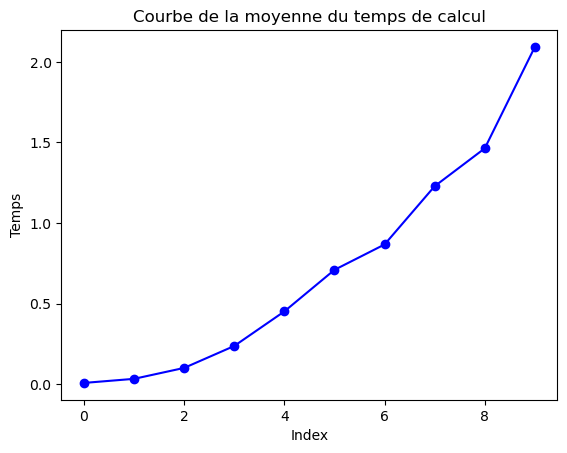

In [17]:
plt.plot(liste_moyenne_time, label='Courbe des valeurs', color='b', marker='o')

# Ajout des labels et du titre
plt.xlabel('Index')  # Axe des x (index des éléments)
plt.ylabel('Temps')  # Axe des y (valeurs de la liste)
plt.title('Courbe de la moyenne du temps de calcul')
# Affichage du graphique
plt.show()

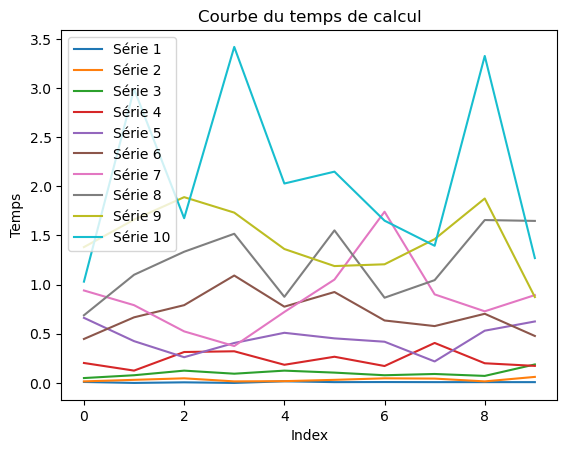

In [18]:
# Tracer les courbes pour chaque sous-liste dans 'data'
for i, subset in enumerate(average_times):
    plt.plot(subset, label=f'Série {i+1}')

# Ajouter des labels et un titre
plt.xlabel('Index')
plt.ylabel('Temps')
plt.title('Courbe du temps de calcul')

# Ajouter une légende
plt.legend()

# Afficher le graphique
plt.show()

In [19]:
from gurobipy import Model, GRB

ModuleNotFoundError: No module named 'gurobipy'

In [15]:
from pulp import*

In [18]:
#Question 12
def solve_assignment(n_etud, n_parcours, capacities, matrice_prefs_etud, k):
    """
    n_etud -> list*int : nombre d etudiant
    n_parcours -> list*int : nombre d option
    matrice_prefs_etud -> list*list*str : les preferences des etudiants
    k -> k premiers choix : k premiers choix
    
    La fonction permet de savoir s il existe une affctation ou tout etudiant a un de ses k premiers choix ou non
    
    Return : la solution , si il est trouve sinon None
    """
    model = LpProblem("Assignement des etudiants", LpMinimize)
    
    # Variables de decision : x[i, j] = 1 si l etudiant i est affecte a l'option j
    #creation d un dictionnaire pour stocker le nom de la variable x_i,j, et declation des variables
    x = {(i, j): LpVariable(f"x_{int(i)},{j}", cat=LpBinary) for i in range(n_etud) for j in range(n_parcours)}
    #print(x)
    # Chaque etudiant est affecté a une seule option
    #Definition de la fonction objectif :x_i,j + ...+ x_i+n,j+m = 1
    for i in range(n_etud):
        model += lpSum(x[i, j] for j in range(n_parcours)) == 1
    # Chaque option respecte sa capacité maximale
    for j in range(n_parcours):
        model += lpSum(x[i, j] for i in range(n_etud)) <= capacities[j]
    #print(model)
    # Chaque etudiant doit etre affecte a l une de ses k premieres options
    for i in range(n_parcours):
        allouer_options = matrice_prefs_etud[i][:k]  # On prend les k premieres options preferees
        model += lpSum(x[i, int(j)] for j in allouer_options) == 1
    #print(model)
    # Resolution du probleme
    model.solve(solver=GLPK(msg=True,keepFiles=True))
    if model.status == 1:
        print("Solution trouvée")
        return {(i, int(j)): x[i, int(j)].varValue for i in range(n_etud) for j in range(n_parcours) if x[i, int(j)].varValue > 0.5}
    else:
        print("Aucune solution trouvée")
        return None

# Q12
n_etud = 11
n_parcours = 9
k = 3 
result = solve_assignment(n_etud, n_parcours, capacite, matrix_pref_etu, k)
print("Affectation:", result)

Aucune solution trouvée
Affectation: None


In [19]:
#Question 13
def find_min_k(n_etud, n_parcours, matrice_pref_etud,capacite):
    """
    n_students -> list*int : nombre d etudiant
    n_options -> list*int : nombre d option
    matrice_prefs -> list*list*str : les preferences des etudiants
    
    Fonction qui troue le plus petit k
    
    Return : une solution maximsant l utilite minimale des etudiants
    """
    for k in range(1, n_parcours + 1):# k+1
        solution= solve_assignment(n_etud, n_parcours, capacite, matrice_pref_etud, k)
        if solution:#si la reponse est different de None alors cest le plus petit k, mais si on ne trouve aucune solution a la fin de la boucle alors il ny a pas de solution
            print(f"Le plus petit k permettant de trouver une solution est de {k}")
            return solution
    print("Aucune solution possible")
    return None

In [21]:
#Q13
result1=find_min_k(n_etud,n_parcours,matrix_pref_etu,capacite)
result1

Aucune solution trouvée
Aucune solution trouvée
Aucune solution trouvée
Solution trouvée
Le plus petit k permettant de trouver une solution est de 4


{(0, 8): 1,
 (1, 6): 1,
 (2, 0): 1,
 (3, 0): 1,
 (4, 1): 1,
 (5, 2): 1,
 (6, 5): 1,
 (7, 4): 1,
 (8, 7): 1,
 (9, 3): 1,
 (10, 8): 1}

In [42]:
#Question 14
def solve_max_utile(n_etud, n_parcours, capacities, matrice_prefs_etud, matrice_prefs_parcours):
    """
    n_etud -> list*int : nombre d etudiant
    n_parcours -> list*int : nombre de parcours
    matrice_prefs -> list*list*str : les preferences des etudiants
    k -> k premiers choix : k premiers choix
    
    La fonction permet de trouver une solution qui maximise la somme des utilites(etudiant et parcours) avec glpk
    En plus il donne la moyenne et le minimun de l utilite des etudiants 
    
    Return : la solution 
    """
    model = LpProblem("Maximum Assignement des etudiants",LpMaximize)
    
     # Variables de decision : x[i, j] = 1 si l etudiant i est affecte a l'option j
    #creation d un dictionnaire pour stocker le nom de la variable x_i,j, et declation des variables
    x = {(i, j): LpVariable(f"x_{int(i)},{j}", cat=LpBinary) for i in range(n_etud) for j in range(n_parcours)}
    #print(x)
    # Chaque etudiant est affecté a une seule option
    #Definition de la fonction objectif :x_i,j + ...+ x_i+n,j+m = 1
    for i in range(n_etud):
        model += lpSum(x[i, j] for j in range(n_parcours)) == 1
    # Chaque option respecte sa capacité maximale
    for j in range(n_parcours):
        model += lpSum(x[i, j] for i in range(n_etud)) <= capacities[j]
    #print(model)
    # Definition de l objectif : maximiser la somme des utilites (etudiants et parcours)
    model += lpSum(int(matrice_prefs_etud[i][j]) * x[i, j] for i in range(n_etud) for j in range(n_parcours)) + \
             lpSum(int(matrice_prefs_parcours[j][i]) * x[i, j] for i in range(n_etud) for j in range(n_parcours))
    
    # Resolution du problème
    model.solve(solver=GLPK(msg=True,keepFiles=True))
    
    values = [sum(int(matrice_prefs_etud[i][j]) * x[i, j].varValue for j in range(n_parcours)) for i in range(n_etud)]
    print(f"On obtient l'utilité minimale des étudiants : {min(values)}")
    print(f"On obtient l'utilité moyenne des étudiants : {sum(values) / n_etud}")
    
    return {(i, j): x[i, j].varValue for i in range(n_etud) for j in range(n_parcours) if x[i, j].varValue > 0.5}


In [50]:
result2 = solve_max_utile(n_etud, n_parcours, capacite, matrix_pref_etu,matrix_pref_spe)
print("Affectation:", result2)

On obtient l'utilité minimale des étudiants : 4
On obtient l'utilité moyenne des étudiants : 6.2727272727272725
Affectation: {(0, 3): 1, (1, 0): 1, (2, 7): 1, (3, 5): 1, (4, 2): 1, (5, 8): 1, (6, 4): 1, (7, 0): 1, (8, 1): 1, (9, 6): 1, (10, 8): 1}


In [51]:
#Question 15
def solve_max_utile_k(n_etud, n_parcours, capacities, matrice_prefs_etud, matrice_prefs_parcours,k):
    """
    n_etud -> list*int : nombre d etudiant
    n_parcours -> list*int : nombre de parcours
    matrice_prefs -> list*list*str : les preferences des etudiants
    k -> k premiers choix : k premiers choix
    
    La fonction permet de trouver une solution qui maximise la somme des utilites(etudiant et parcours) avec glpk
    En plus il donne la moyenne et le minimun de l utilite des etudiants 
    
    Return : la solution 
    """
    model = LpProblem("Maximum Assignement des etudiants",LpMaximize)
    
     # Variables de decision : x[i, j] = 1 si l etudiant i est affecte a l'option j
    #creation d un dictionnaire pour stocker le nom de la variable x_i,j, et declation des variables
    x = {(i, j): LpVariable(f"x_{int(i)},{j}", cat=LpBinary) for i in range(n_etud) for j in range(n_parcours)}
    #print(x)
    # Chaque etudiant est affecté a une seule option
    #Definition de la fonction objectif :x_i,j + ...+ x_i+n,j+m = 1
    for i in range(n_etud):
        model += lpSum(x[i, int(j)] for j in matrice_prefs_etud[i][:k]) == 1
    # Chaque option respecte sa capacité maximale
    for j in range(n_parcours):
        model += lpSum(x[i, j] for i in range(n_etud)) <= capacities[j]
    #print(model)
    # Definition de l objectif : maximiser la somme des utilites (etudiants et parcours)
    model += lpSum(int(matrice_prefs_etud[i][j]) * x[i, j] for i in range(n_etud) for j in range(n_parcours)) + \
             lpSum(int(matrice_prefs_parcours[j][i]) * x[i, j] for i in range(n_etud) for j in range(n_parcours))
    
    # Resolution du problème
    model.solve(solver=GLPK(msg=True,keepFiles=True))
    
    values = [sum(int(matrice_prefs_etud[i][j]) * x[i, j].varValue for j in range(n_parcours)) for i in range(n_etud)]
    print(f"On obtient l'utilité minimale des étudiants : {min(values)}")
    print(f"On obtient l'utilité moyenne des étudiants : {sum(values) / n_etud}")
    
    return {(i, j): x[i, j].varValue for i in range(n_etud) for j in range(n_parcours) if x[i, j].varValue > 0.5}

In [53]:
result3=solve_max_utile_k(n_etud, n_parcours, capacite, matrix_pref_etu,matrix_pref_spe,5)
result3

On obtient l'utilité minimale des étudiants : 4
On obtient l'utilité moyenne des étudiants : 6.0


{(0, 3): 1,
 (1, 0): 1,
 (2, 7): 1,
 (3, 5): 1,
 (4, 1): 1,
 (5, 4): 1,
 (6, 8): 1,
 (7, 0): 1,
 (8, 2): 1,
 (9, 6): 1,
 (10, 8): 1}

In [54]:
#Question 16
def convertir(dictionnaire):
    return {str(cle):str(valeur) for cle,valeur in dictionnaire}

In [55]:
#Etudiant
affectation4=convertir(result1)
print(affectation4)
affectation5=convertir(result2)
print(affectation5)
affectation6=convertir(result3)
print(affectation6)


{'0': '8', '1': '6', '2': '0', '3': '0', '4': '1', '5': '2', '6': '5', '7': '4', '8': '7', '9': '3', '10': '8'}
{'0': '3', '1': '0', '2': '7', '3': '5', '4': '2', '5': '8', '6': '4', '7': '0', '8': '1', '9': '6', '10': '8'}
{'0': '3', '1': '0', '2': '7', '3': '5', '4': '1', '5': '4', '6': '8', '7': '0', '8': '2', '9': '6', '10': '8'}


In [56]:
print("Liste des paires instables Q13  :", paire_instables(affectation4, matrix_pref_spe,matrix_pref_etu))

Liste des paires instables Q13  : [('0', '6'), ('5', '0'), ('7', '0'), ('10', '0'), ('9', '2'), ('0', '5'), ('3', '5'), ('5', '4'), ('10', '4'), ('0', '7'), ('3', '7'), ('5', '7'), ('7', '7'), ('9', '8')]


In [57]:
print("Liste des paires instables Q14 :", paire_instables(affectation4, matrix_pref_spe,matrix_pref_etu))

Liste des paires instables Q14 : [('0', '6'), ('5', '0'), ('7', '0'), ('10', '0'), ('9', '2'), ('0', '5'), ('3', '5'), ('5', '4'), ('10', '4'), ('0', '7'), ('3', '7'), ('5', '7'), ('7', '7'), ('9', '8')]


In [58]:
print("Liste des paires instables Q15 :", paire_instables(affectation6, matrix_pref_spe,matrix_pref_etu))

Liste des paires instables Q15 : [('5', '0'), ('0', '7'), ('5', '7'), ('6', '7'), ('7', '7'), ('8', '7'), ('0', '5'), ('1', '5'), ('10', '4'), ('0', '8'), ('6', '2'), ('9', '2'), ('0', '6'), ('1', '6'), ('3', '6'), ('6', '6'), ('8', '6'), ('10', '6')]


In [103]:
def moyenne_et_min(couple, matrice_pref):
    """Calcule l'utilité moyenne et minimale des étudiants."""
    tmp = []
    
    # Convertir toute la matrice des préférences en entiers
    matrice_pref = [[int(x) for x in ligne] for ligne in matrice_pref]

    for i in range(len(matrice_pref)):
        affectation = int(couple[str(i)])  # S'assurer que l'affectation est un entier
        
        if affectation in matrice_pref[i]:  # Vérification avant de chercher l'index
            tmp.append(matrice_pref[i].index(affectation))

    return sum(tmp) / len(tmp), min(tmp)
utilite_moyenne, utilite_minimale = moyenne_et_min(result_etu_gale, matrix_pref_etu)
print(f"Utilité moyenne : {utilite_moyenne}")
print(f"Utilité minimale : {utilite_minimale}")

Utilité moyenne : 1.5454545454545454
Utilité minimale : 0


In [111]:
def moyenne_et_min_spe(couple, matrice_pref):
    """Calcule l'utilité moyenne et minimale des options par rapport aux étudiants affectés."""
    tmp = []
    
    # Convertir la matrice des préférences en entiers
    matrice_pref = [[int(x) for x in ligne] for ligne in matrice_pref]

    for option, students in couple.items():
        for student in students:  # Parcourir chaque étudiant affecté à cette option
            student = int(student)  # S'assurer que l'étudiant est un entier
            option = int(option)  # S'assurer que l'option est un entier
            
            if student in matrice_pref[option]:  # Vérifier si l'étudiant est dans la liste des préférences de l'option
                tmp.append(matrice_pref[option].index(student))

    return sum(tmp) / len(tmp), min(tmp)
utilite_moyenne, utilite_minimale = moyenne_et_min_spe(result_spe_gale, matrix_pref_spe)
print(f"Utilité moyenne : {utilite_moyenne}")
print(f"Utilité minimale : {utilite_minimale}")

Utilité moyenne : 2.8181818181818183
Utilité minimale : 0
